In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Edit these two paths ──────────────────────────────────────────────────────
DATA_DIR   = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\tab"
OUTPUT_DIR = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\outputs"
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
tab_files = glob.glob(os.path.join(DATA_DIR, "*.tab"))
print(f"Found {len(tab_files)} file(s):")
for f in tab_files:
    print(" ", os.path.basename(f))

dfs = [pd.read_csv(f, sep="\t", low_memory=False, encoding="latin-1") for f in tab_files]
df_raw = pd.concat(dfs, ignore_index=True)

print(f"\nShape: {df_raw.shape}")
print(f"\nFirst 5 columns: {list(df_raw.columns[:5])}")
df_raw.head(3)

Found 3 file(s):
  active_lives_survey_child_202324_main_shared.tab
  active_lives_survey_child_202324_teacher_shared_20250314.tab
  active_lives_survey_child_202324_yr1-2_shared_20250314_.tab

Shape: (142167, 5942)

First 5 columns: ['Respondent_Serial', 'WhereChild2_bcd', 'term', 'halfterm', 'wt_gross']


,Respondent_Serial,WhereChild2_bcd,term,halfterm,wt_gross,xcluster,xSCHYR_5_2,xstrata,xsurvey_year,Region_name,...,WEEKAC1_A03,WEEKAC1_A04,WEEKAC1_A05,WEEKAC1_A06,WEEKAC1_A07,WEEKAC1_A08,WEEKAC1_A09,WEEKAC1_A10,WEEKAC1_A11,WEEKAC1_A12
0,102535,1.0,2,3.0,342.912648,37000553.0,1.0,11017.0,7.0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,128793,2.0,2,4.0,81.546520,37000553.0,2.0,11017.0,7.0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,129552,2.0,2,4.0,81.546520,37000553.0,2.0,11017.0,7.0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
geo_candidates = [c for c in df_raw.columns if any(
    kw in c.lower() for kw in ["region", "la_", "lad", "local", "borough", "area", "geo"]
)]
print("Geography columns found:", geo_candidates)

# Print unique values of each to spot London codes
for col in geo_candidates[:8]:
    vals = df_raw[col].dropna().unique()
    print(f"\n{col}:\n  {vals[:20]}")

Geography columns found: ['Region_name']

Region_name:
  [3 8 5 9 4 7 1 6 2]


In [6]:
# Print ALL column names
print("ALL COLUMNS:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i:3d}: {col}")

ALL COLUMNS:
    0: Respondent_Serial
    1: WhereChild2_bcd
    2: term
    3: halfterm
    4: wt_gross
    5: xcluster
    6: xSCHYR_5_2
    7: xstrata
    8: xsurvey_year
    9: Region_name
   10: CSP_name
   11: CSP_name2019
   12: CSP_name2025
   13: CSPNC
   14: CSPNC2019
   15: CSPNC2025
   16: CountyCounc_2023
   17: ICB_2024
   18: ICB24CD
   19: LDP_combined
   20: LDP_proxy
   21: overall
   22: age_11
   23: SCHYR_11
   24: SCHYR_2
   25: SCHYR_2_2
   26: SCHYR_3
   27: SCHYR_5_2
   28: GEND3
   29: FASbandF
   30: FASBandnoHol
   31: eth2
   32: eth6
   33: Disab_All_POP
   34: Disab_Limit_POP
   35: Disab_LT_POP
   36: Disab_LTLimit_POP
   37: Disab_POP
   38: IMPAIR4
   39: IMPAIRLimit4
   40: Dis_bcd01_POP
   41: Dis_bcd02_POP
   42: Dis_bcd03_POP
   43: Dis_bcd04_POP
   44: Dis_bcd05_POP
   45: Dis_bcd06_POP
   46: Dis_bcd07_POP
   47: Dis_bcd08_POP
   48: Dis_bcd09_POP
   49: Dis_bcd10_POP
   50: Dis_bcd11_POP
   51: Dis_bcd12_POP
   52: Dis_bcd13_POP
   53: Dis_bcd14

In [7]:
print("Geo candidates:", geo_candidates)
print()
for col in geo_candidates:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts().head(20))
    print()

Geo candidates: ['Region_name']

--- Region_name ---
Region_name
1    25051
2    22475
6    22084
5    18214
8    14395
3    11905
9    11632
7    10426
4     5985
Name: count, dtype: int64



In [8]:
# Check all the name/geography columns visible in your column list
cols_to_check = ['Region_name', 'WhereChild2_bcd', 'CSP_name', 'CSP_name2019', 
                 'CSP_name2025', 'CSPNC', 'CSPNC2019', 'CSPNC2025', 'CountyCounc_2023']

for col in cols_to_check:
    if col in df_raw.columns:
        print(f"\n--- {col} ---")
        print(df_raw[col].value_counts().head(25))


--- Region_name ---
Region_name
1    25051
2    22475
6    22084
5    18214
8    14395
3    11905
9    11632
7    10426
4     5985
Name: count, dtype: int64

--- WhereChild2_bcd ---
WhereChild2_bcd
2.0    121361
1.0      1119
Name: count, dtype: int64

--- CSP_name ---
CSP_name
25    11905
10     8825
22     8146
14     7340
31     6014
18     6000
1      5726
16     5240
19     5004
39     4875
21     4852
17     4479
38     3913
23     3820
20     3728
40     3572
44     3514
37     3344
4      3023
35     3004
27     2883
24     2822
9      2469
33     2207
32     2018
Name: count, dtype: int64

--- CSP_name2019 ---
CSP_name2019
46    14839
25    11905
22     8146
14     7340
47     6518
18     6000
1      5726
16     5240
19     5004
39     4875
21     4852
17     4479
38     3913
23     3820
20     3728
40     3572
37     3344
4      3023
27     2883
24     2822
9      2469
48     2290
33     2207
32     2018
26     1971
Name: count, dtype: int64

--- CSP_name2025 ---
CSP_name202

In [11]:
base = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab"

for root, dirs, files in os.walk(base):
    for f in files:
        print(os.path.join(root, f))

C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\9533_file_information.rtf
C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\read9533.htm
C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\mrdoc\ukda_data_dictionaries.zip
C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\mrdoc\excel\9533_active_lives_cyp_y7_2023-24_code_book_year_7.xlsx
C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\mrdoc\pdf\9533_active_lives_child_y7_2023-24_data_user_guide.pdf
C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\mrdoc\pdf\9533_active_lives_cyp_y7_2023-2024_privacy_policy.pdf
C:\Users\ouame\Downloads\9533tab_F719F73F4

In [12]:
CODEBOOK = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\mrdoc\excel\9533_active_lives_cyp_y7_2023-24_code_book_year_7.xlsx"

# See what sheets are in the codebook
xl = pd.ExcelFile(CODEBOOK)
print(xl.sheet_names)

['About this document', 'Measures', 'Activity code list', 'Activity composite links', 'Minutes assumptions', 'Intensity assumptions', 'Indoor_outdoor assumptions']


In [13]:
# Read the first few sheets to find the region/CSP value labels
for sheet in xl.sheet_names[:5]:
    print(f"\n=== Sheet: {sheet} ===")
    df_cb = pd.read_excel(CODEBOOK, sheet_name=sheet, nrows=5)
    print(df_cb)


=== Sheet: About this document ===
   Unnamed: 0  Unnamed: 1                                         Unnamed: 2
0         NaN         NaN                                                NaN
1         NaN         NaN  Active Lives Children and Young People Code Bo...

=== Sheet: Measures ===
                    Type_of_variable      DV prefix/ Variable name  \
0  Key activity measures from report  mins_modplus_everywhere_week   
1  Key activity measures from report                Week_30plus_MP   
2  Key activity measures from report               onceawk_modplus   
3  Key activity measures from report                   SwmCan_bcd    
4  Key activity measures from report             Swm25Can_bcd_POP    

                                             Measure  \
0  Minutes of moderate or vigorous intensity per ...   
1  Whether does an average of 30 plus minutes of ...   
2  Once a week participation in moderate plus act...   
3                                   Whether can swim   
4      

In [14]:
MAIN_TAB = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\tab\active_lives_survey_child_202324_main_shared.tab"

df_raw = pd.read_csv(MAIN_TAB, sep="\t", low_memory=False, encoding="latin-1")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

Shape: (122480, 5454)
Columns: ['Respondent_Serial', 'WhereChild2_bcd', 'term', 'halfterm', 'wt_gross', 'xcluster', 'xSCHYR_5_2', 'xstrata', 'xsurvey_year', 'Region_name', 'CSP_name', 'CSP_name2019', 'CSP_name2025', 'CSPNC', 'CSPNC2019', 'CSPNC2025', 'CountyCounc_2023', 'ICB_2024', 'ICB24CD', 'LDP_combined', 'LDP_proxy', 'overall', 'age_11', 'SCHYR_11', 'SCHYR_2', 'SCHYR_2_2', 'SCHYR_3', 'SCHYR_5_2', 'GEND3', 'FASbandF', 'FASBandnoHol', 'eth2', 'eth6', 'Disab_All_POP', 'Disab_Limit_POP', 'Disab_LT_POP', 'Disab_LTLimit_POP', 'Disab_POP', 'IMPAIR4', 'IMPAIRLimit4', 'Dis_bcd01_POP', 'Dis_bcd02_POP', 'Dis_bcd03_POP', 'Dis_bcd04_POP', 'Dis_bcd05_POP', 'Dis_bcd06_POP', 'Dis_bcd07_POP', 'Dis_bcd08_POP', 'Dis_bcd09_POP', 'Dis_bcd10_POP', 'Dis_bcd11_POP', 'Dis_bcd12_POP', 'Dis_bcd13_POP', 'Dis_bcd14_POP', 'Dis_bcd15_POP', 'Dis_bcd16_POP', 'disLTLimit_bcd01_POP', 'disLTLimit_bcd02_POP', 'disLTLimit_bcd03_POP', 'disLTLimit_bcd04_POP', 'disLTLimit_bcd05_POP', 'disLTLimit_bcd06_POP', 'disLTLimit_bc

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

MAIN_TAB = r"C:\Users\ouame\Downloads\9533tab_F719F73F43AC1F412F0606FEAFC8256F436B062940CE43B426F384547BB3B5F5_V1\UKDA-9533-tab\tab\active_lives_survey_child_202324_main_shared.tab"

df_raw = pd.read_csv(MAIN_TAB, sep="\t", low_memory=False, encoding="latin-1")
print(f"Shape: {df_raw.shape}")

Shape: (122480, 5454)


In [16]:
# Sport England region 7 = London
df_london = df_raw[df_raw['Region_name'] == 7].copy()
print(f"London rows: {len(df_london)}")

London rows: 9027


In [17]:
# These are the exact column names confirmed in the dataset
key_cols = [
    'Respondent_Serial',
    'Region_name',
    'CSP_name',          # borough-level code (we'll label these below)
    'wt_gross',          # survey weight
    'GEND3',             # gender (1=Boy, 2=Girl, 3=Other)
    'SCHYR_5_2',         # school year group
    'eth6',              # ethnicity (6 categories)
    'Disab_All_POP',     # any disability
    'IMD_QUINTILE',      # deprivation quintile (1=most deprived)
    'IMDDECILE',         # deprivation decile
    'urbanrural2',       # urban/rural
    # Physical activity outcomes
    'mins_modplus_everywhere_Week_ALL',   # total weekly mod+ activity minutes
    'mins_modplus_inschool_Week_ALL',     # in-school mod+ minutes
    'mins_modplus_outschool_Week_ALL',    # out-of-school mod+ minutes
    'Week_60plus_MP_ALL_GR4',            # days/week with 60+ mins (grouped)
    'DAYSNUMMPWK_everywhere',            # number of days active
    'Days_60plus_MP_ALL',                # days achieving 60-min guideline
    # Wellbeing
    'WellB_Happy',
    'WellB_Lifesat',
    # Active travel
    'SchTrav_bcd_ACTIVE',                # active travel to school
    # School
    'Daily_mile',                        # Daily Mile participation
]

# Only keep columns that exist
key_cols = [c for c in key_cols if c in df_london.columns]
df = df_london[key_cols].copy()
print(f"Working dataset: {df.shape}")
print(df.head(3))

Working dataset: (9027, 21)
       Respondent_Serial  Region_name  CSP_name    wt_gross  GEND3  SCHYR_5_2  \
11263             185354            7        43  138.047660      2          1   
11264             185495            7        43  218.177062      2          1   
11265             186435            7        43  135.938337      1          1   

       eth6  Disab_All_POP  IMD_QUINTILE  IMDDECILE  ...  \
11263     1              1             3          6  ...   
11264     1              3             3          6  ...   
11265     1              1             3          6  ...   

       mins_modplus_everywhere_Week_ALL  mins_modplus_inschool_Week_ALL  \
11263                               340                              80   
11264                               185                              40   
11265                              1115                             190   

       mins_modplus_outschool_Week_ALL  Week_60plus_MP_ALL_GR4  \
11263                              260 

In [18]:
# CSP_name codes for London boroughs (from Sport England geography)
# These are the 2025 CSP codes covering London
london_csp_names = {
    1:  'Barking & Dagenham / Havering / Redbridge',
    2:  'Barnet / Enfield / Haringey',
    3:  'Bexley / Bromley / Greenwich',
    4:  'Brent / Harrow',
    5:  'Camden / Islington',
    6:  'City of London / Hackney / Tower Hamlets',
    7:  'Croydon / Merton / Sutton / Wandsworth',
    8:  'Ealing / Hammersmith & Fulham / Hounslow',
    9:  'Kingston / Richmond',
    10: 'Lambeth / Southwark',
    11: 'Lewisham',
    12: 'Newham',
    13: 'Waltham Forest',
    14: 'Westminster / Kensington & Chelsea',
}

# Check which CSP codes actually appear in the London subset
print("CSP codes in London data:")
print(df['CSP_name'].value_counts().sort_index())

CSP codes in London data:
CSP_name
8     1673
11    1515
12    1003
15    1247
34    1167
43    1522
45     900
Name: count, dtype: int64


In [19]:
# Replace UKDS missing value codes with NaN
MISSING = [-1, -8, -9, -99, 99, 999, 9999]
df.replace(MISSING, np.nan, inplace=True)

# Cast numeric columns
num_cols = ['mins_modplus_everywhere_Week_ALL', 'mins_modplus_inschool_Week_ALL',
            'mins_modplus_outschool_Week_ALL', 'DAYSNUMMPWK_everywhere',
            'Days_60plus_MP_ALL', 'IMD_QUINTILE', 'IMDDECILE', 'WellB_Happy', 'WellB_Lifesat']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Gender labels (GEND3: 1=Boy, 2=Girl, 3=Other/prefer not to say)
df['gender_label'] = df['GEND3'].map({1: 'Boy', 2: 'Girl', 3: 'Other'})

# School year → age band
yr_map = {1:'Yr1-2', 2:'Yr1-2', 3:'Yr3-4', 4:'Yr3-4',
          5:'Yr5-6', 6:'Yr5-6', 7:'Yr7-8', 8:'Yr7-8',
          9:'Yr9-10', 10:'Yr9-10', 11:'Yr11'}
df['year_band'] = df['SCHYR_5_2'].map(yr_map)

# Ethnicity labels (eth6)
eth_map = {1:'White British', 2:'White Other', 3:'Mixed',
           4:'Asian', 5:'Black', 6:'Other'}
df['ethnicity_label'] = df['eth6'].map(eth_map)

# Binary: meets 60-min/day guideline on average
# Days_60plus_MP_ALL = number of days in the past week with 60+ mins
# "Active" = 7 days (daily); use Week_60plus_MP_ALL_GR4 if available
if 'Week_60plus_MP_ALL_GR4' in df.columns:
    # GR4 grouping: check what codes mean
    print("Week_60plus_MP_ALL_GR4 values:")
    print(df['Week_60plus_MP_ALL_GR4'].value_counts().sort_index())

# Binary active flag: 60+ mins mod activity per day on average
# = total weekly mins >= 420 (7 x 60)
if 'mins_modplus_everywhere_Week_ALL' in df.columns:
    df['meets_guideline'] = (df['mins_modplus_everywhere_Week_ALL'] >= 420).astype(float)
    df.loc[df['mins_modplus_everywhere_Week_ALL'].isna(), 'meets_guideline'] = np.nan

# Missing value summary
print("\nMissing values (%) in key columns:")
display(df[['gender_label','year_band','ethnicity_label','IMD_QUINTILE',
            'mins_modplus_everywhere_Week_ALL','meets_guideline']].isnull().mean().mul(100).round(1))

Week_60plus_MP_ALL_GR4 values:
Week_60plus_MP_ALL_GR4
1    1811
2    2602
3    1978
4    2636
Name: count, dtype: int64

Missing values (%) in key columns:


gender_label                         9.3
year_band                            0.0
ethnicity_label                     10.6
IMD_QUINTILE                         0.0
mins_modplus_everywhere_Week_ALL     0.0
meets_guideline                      0.0
dtype: float64

In [21]:
OUTPUT_DIR = r"C:\Users\ouame\Downloads\active lives"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_path = os.path.join(OUTPUT_DIR, "london_cyp_2324_clean.csv")
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  |  Shape: {df.shape}")

Saved: C:\Users\ouame\Downloads\active lives\london_cyp_2324_clean.csv  |  Shape: (9027, 25)


In [22]:
print("=== Overall London: % meeting 60-min/day guideline ===")
pct = df['meets_guideline'].mean() * 100
print(f"{pct:.1f}%  ({df['meets_guideline'].notna().sum()} respondents)")

print("\n=== By Gender ===")
display(df.groupby('gender_label')['meets_guideline'].mean().mul(100).round(1).rename('% Active'))

print("\n=== By School Year Band ===")
display(df.groupby('year_band')['meets_guideline'].mean().mul(100).round(1).rename('% Active'))

print("\n=== By Deprivation Quintile (1=most deprived) ===")
display(df.groupby('IMD_QUINTILE')['meets_guideline'].mean().mul(100).round(1).rename('% Active'))

print("\n=== By Ethnicity ===")
display(df.groupby('ethnicity_label')['meets_guideline'].mean().mul(100).round(1).rename('% Active'))

print("\n=== Average weekly mod+ activity minutes by gender ===")
display(df.groupby('gender_label')['mins_modplus_everywhere_Week_ALL'].mean().round(1))

=== Overall London: % meeting 60-min/day guideline ===
48.0%  (9027 respondents)

=== By Gender ===


gender_label
Boy      50.5
Girl     46.2
Other    50.0
Name: % Active, dtype: float64


=== By School Year Band ===


year_band
Yr1-2    43.3
Yr3-4    48.6
Yr5-6    49.7
Name: % Active, dtype: float64


=== By Deprivation Quintile (1=most deprived) ===


IMD_QUINTILE
1    44.7
2    47.9
3    47.4
4    47.3
5    50.9
Name: % Active, dtype: float64


=== By Ethnicity ===


ethnicity_label
Asian            41.0
Black            48.3
Mixed            40.1
Other            48.1
White British    49.6
White Other      46.3
Name: % Active, dtype: float64


=== Average weekly mod+ activity minutes by gender ===


gender_label
Boy      600.4
Girl     513.7
Other    551.8
Name: mins_modplus_everywhere_Week_ALL, dtype: float64

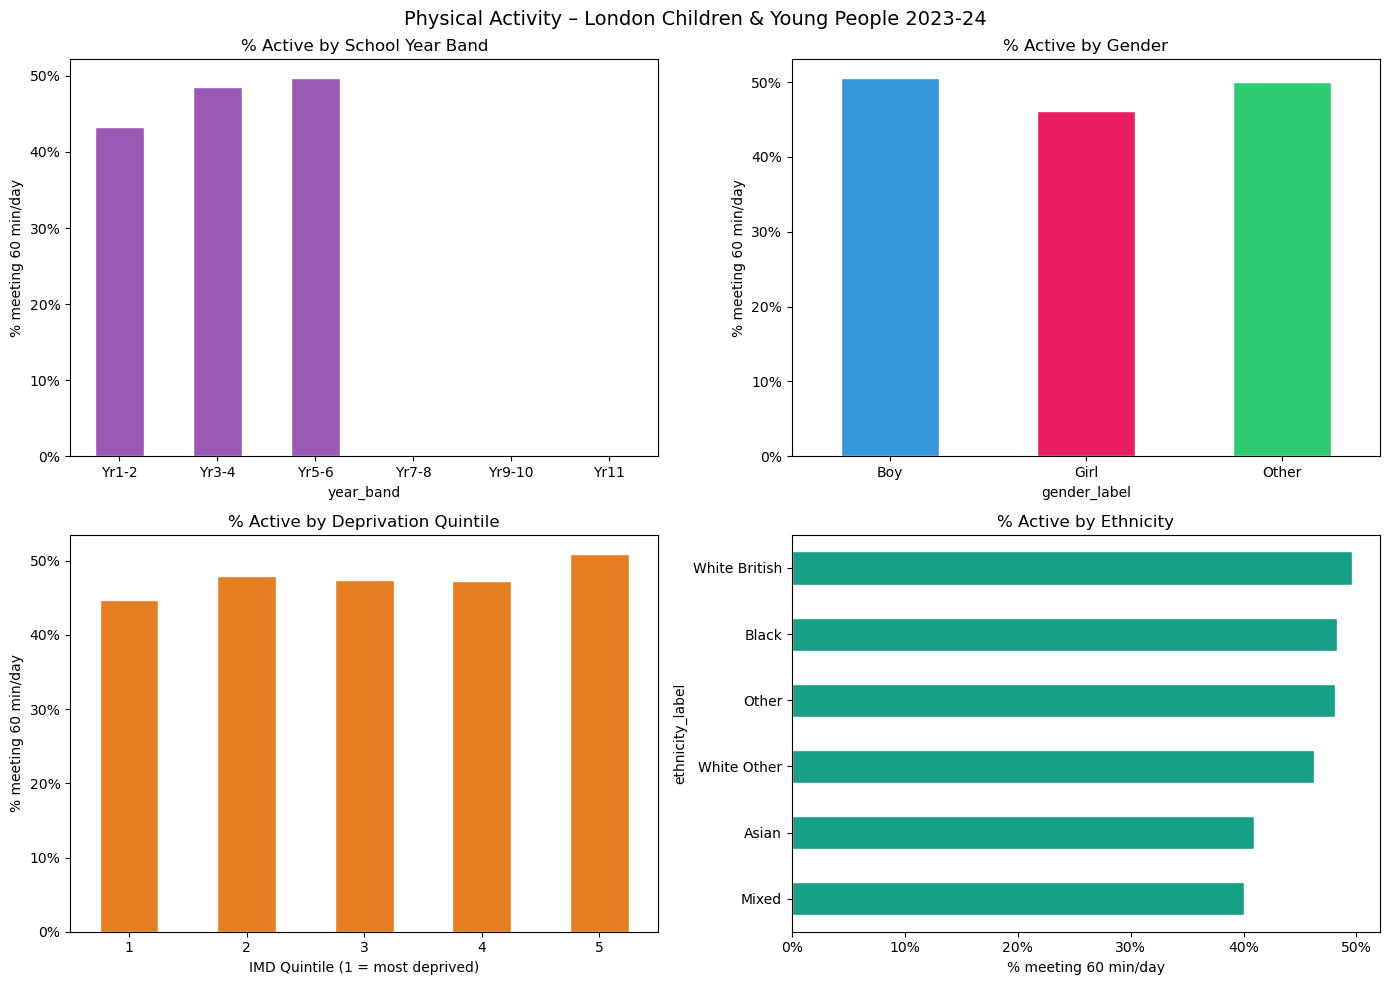

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Physical Activity – London Children & Young People 2023-24", fontsize=14)

# 1. By school year band
ax = axes[0, 0]
order = ['Yr1-2','Yr3-4','Yr5-6','Yr7-8','Yr9-10','Yr11']
data = df.groupby('year_band')['meets_guideline'].mean().mul(100).reindex(order)
data.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white', rot=0)
ax.set_title('% Active by School Year Band')
ax.set_ylabel('% meeting 60 min/day')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# 2. By gender
ax = axes[0, 1]
df.groupby('gender_label')['meets_guideline'].mean().mul(100).plot(
    kind='bar', ax=ax, color=['#3498db','#e91e63','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('% Active by Gender')
ax.set_ylabel('% meeting 60 min/day')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# 3. By deprivation
ax = axes[1, 0]
df.groupby('IMD_QUINTILE')['meets_guideline'].mean().mul(100).plot(
    kind='bar', ax=ax, color='#e67e22', edgecolor='white', rot=0)
ax.set_title('% Active by Deprivation Quintile')
ax.set_xlabel('IMD Quintile (1 = most deprived)')
ax.set_ylabel('% meeting 60 min/day')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# 4. By ethnicity
ax = axes[1, 1]
df.groupby('ethnicity_label')['meets_guideline'].mean().mul(100).sort_values().plot(
    kind='barh', ax=ax, color='#16a085', edgecolor='white')
ax.set_title('% Active by Ethnicity')
ax.set_xlabel('% meeting 60 min/day')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()